<details>
<summary><b>Info</b></summary>

**Last Execution:** 2026-08-05

| Package | Version |
|---------|---------|
| **nnsight** | **0.8** |
| Python | 3.12.13 |
| torch | 2.13.0+cu126 |
| transformers | 5.15.0 |

</details>

# The Logit Lens Over Image Tokens

## Introduction

👁️ A vision-language model like **LLaVA-1.5** is a language model with pictures spliced into
its input. A CLIP vision tower encodes the image into 576 patch embeddings, a small projector
maps them into the language model's embedding space, and from there they are just *tokens* —
576 of them, sitting in the sequence alongside the text, running through the same 32 Llama
decoder layers.

Which raises the question this paper asks: if the image patches are tokens in a language
model's sequence, **can you read them as language?**

The [logit lens](../tutorials/probing/logit_lens.ipynb) is the obvious instrument. At each
layer, apply the model's own final norm and unembedding to the residual stream, as if that
layer were the last, and read off the most likely token. Normally you do this at the text
positions to watch a prediction form. Here we do it at the **image** positions, where there is
no next token to predict — so whatever comes out is the model's own description of what that
patch contains.

Laid back out on the 24 × 24 patch grid, the result is a crude segmentation map: *this corner
is "tree", that blob is "dog"*, produced by a model that was never trained to segment
anything.

📗 [*Towards Interpreting Visual Information Processing in Vision-Language Models*](https://arxiv.org/abs/2410.07149)
(Neo, Ong, Torr, Geva, Krueger, Barez, 2024). Adapted from the CVPR 2026 HOW workshop
[companion code](https://github.com/JadenFiotto-Kaufman/CVPR2026-HOW).

## Setup

If using Colab, install NNsight:
```
!pip install -U nnsight
```

In [1]:
try:
    import google.colab
    is_colab = True
except ImportError:
    is_colab = False

if is_colab:
    !pip install -U nnsight

In [2]:
import hashlib
import io
from collections import Counter

import requests
import PIL.Image
import numpy as np
import matplotlib.colors
import matplotlib.pyplot as plt
import torch
import nnsight
from nnsight import TransformersModel

A vision-language model loads as a `TransformersModel` with the image-text-to-text task. That
gives it a **processor** rather than a bare tokenizer — the thing that turns a PIL image plus a
prompt string into `input_ids` and `pixel_values`.

In [3]:
llava = TransformersModel(
    "llava-hf/llava-1.5-7b-hf",
    task="image-text-to-text",
    dtype=torch.float16,
    device_map="cuda",
    dispatch=True,
)

decoder_layers = llava.model.language_model.layers
print(f"{len(decoder_layers)} decoder layers, processor: {type(llava.processor).__name__}")

32 decoder layers, processor: LlavaProcessor


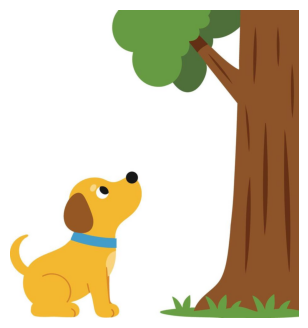

In [4]:
IMAGE_URL = (
    "https://raw.githubusercontent.com/JadenFiotto-Kaufman/CVPR2026-HOW"
    "/master/3_VLM_Lens/images/img.jpg"
)
PROMPT = "USER: <image>\nDescribe the image. ASSISTANT:"

image = PIL.Image.open(io.BytesIO(requests.get(IMAGE_URL, timeout=30).content)).convert("RGB")

plt.figure(figsize=(4, 4))
plt.imshow(image)
plt.axis("off")
plt.show()

A flat cartoon, deliberately: large regions of unambiguous content — dog, tree trunk, foliage,
grass, blank background — so that a patch-level readout has something legible to be right or
wrong about.

## One trace, every layer

Run the processor yourself and hand the encoded batch to `trace`. The single `<image>`
placeholder in the prompt is expanded by the processor into 576 real positions, so the
sequence the model sees is much longer than the prompt looks.

In [5]:
inputs = llava.processor(images=image, text=PROMPT, return_tensors="pt")

print("processor produced:", list(inputs.keys()))
print("sequence length:   ", inputs["input_ids"].shape[1])

processor produced: ['input_ids', 'attention_mask', 'pixel_values']
sequence length:    593


The lens itself is three lines. `layer.output` is the residual stream after a decoder block;
`llava.model.language_model.norm` and `llava.lm_head` are the model's own final readout, called
ad hoc on a value they would not normally see. Calling a module inside a trace runs its forward
without disturbing its real place in the pass.

We keep only the **top-1 token id** per layer and position. The full distribution would be
32 layers × 593 positions × 32,064 tokens — about 2.4 GB — and we would throw all but the
argmax away.

In [6]:
with llava.trace(inputs):
    top1_per_layer = nnsight.save([])
    for layer in decoder_layers:
        logits = llava.lm_head(llava.model.language_model.norm(layer.output))
        top1_per_layer.append(logits.argmax(dim=-1))

print(f"captured {len(top1_per_layer)} layers, each {tuple(top1_per_layer[0].shape)}")

captured 32 layers, each (1, 593)


## Labelling the positions

To read the result we need to know which positions are image patches. The processor writes
LLaVA's image-token id (`32000`) once per patch, so we can label straight off `input_ids`
rather than re-deriving the expansion.

In [7]:
IMAGE_TOKEN_ID = 32000
GRID = 24  # 24 × 24 = 576 patches

token_ids = inputs["input_ids"][0].tolist()
labels, patches_seen = [], 0
for token_id in token_ids:
    if token_id == IMAGE_TOKEN_ID:
        patches_seen += 1
        labels.append(f"<IMG{patches_seen:03d}>")
    else:
        labels.append(llava.tokenizer.decode([token_id]))

image_positions = [i for i, label in enumerate(labels) if label.startswith("<IMG")]
text_positions = [i for i, label in enumerate(labels) if not label.startswith("<IMG")]

assert len(image_positions) == GRID * GRID
print(f"{len(labels)} positions = {len(image_positions)} image patches "
      f"+ {len(text_positions)} text tokens")

593 positions = 576 image patches + 17 text tokens


In [8]:
def top1_at(layer, position):
    return llava.tokenizer.decode([top1_per_layer[layer][0, position].item()])

## The text positions first

The familiar view, as a control. At each text token, what would the model say if we stopped
here?

In [9]:
sample_layers = [4, 12, 20, 26, 31]
print(f"{'position':>8} {'token':<14} " + " ".join(f"{'L' + str(l):<14}" for l in sample_layers))
print("-" * (24 + 15 * len(sample_layers)))
for position in text_positions:
    row = " ".join(f"{top1_at(layer, position)!r:<14}" for layer in sample_layers)
    print(f"{position:>8} {labels[position]!r:<14} {row}")

position token          L4             L12            L20            L26            L31           
---------------------------------------------------------------------------------------------------
       0 '<s>'          'sierp'        'sierp'        'sierp'        'sierp'        'nobody'      
       1 'US'           'mul'          '<s>'          '<s>'          'MC'           'DA'          
       2 'ER'           'gut'          'arms'         'toire'        'vice'         'NAME'        
       3 ':'            'flex'         'Bras'         'Хронологија'  'How'          'What'        
       4 ''             'jug'          'som'          'som'          'Hi'           '1'           
     581 ''             'idenote'      '만'            'green'        'grass'        '2'           
     582 '\n'           '<s>'          'udi'          'Description'  'Description'  '\n'          
     583 'Des'          'schen'        'mag'          'ember'        'cribe'        'p'           
     584 

The last row is the real prediction — the token the model is about to emit — and it resolves
late, as usual: noise until the low 20s, then `' This'` / `' The'`, the start of a description.
Nothing surprising, which is the point: the lens behaves normally on text.

## Now the image positions

The same readout at the 576 patch positions, counted by frequency. There is no next token here
for the model to predict — these positions are pure content.

In [10]:
print(f"{'layer':>5}  {'distinct':>8}   most common patch tokens")
for layer in range(4, 32, 4):
    patch_tokens = [top1_at(layer, position) for position in image_positions]
    common = Counter(patch_tokens).most_common(5)
    print(f"{layer:>5}  {len(set(patch_tokens)):>8}   "
          + "  ".join(f"{token!r}:{count}" for token, count in common))

layer  distinct   most common patch tokens
    4        92   'dust':159  'steps':71  'chev':26  '&=\\':25  'trees':16
    8       121   'olas':223  'chev':36  '&=\\':24  'ulas':17  'trees':14
   12       126   'olas':202  'tree':63  '&=\\':22  'dust':19  'chev':12
   16       102   'olas':215  'tree':94  'background':20  'ish':15  'trees':14
   20        63   'tree':117  'olas':79  'dog':57  'dust':43  'Brad':32
   24        63   'dimen':126  'tree':120  'dust':51  'press':37  'dog':27
   28        59   'tree':117  'and':97  '\n':88  'dog':39  'a':22


Three regimes, and the middle one is the interesting one.

**Early (layers 4–12)** the readout is junk — `'dust'`, `'chev'`, `'olas'`. These are not
descriptions; they are whatever the unembedding happens to point at when handed a vector that
is not yet in the language model's space.

**Middle (16–26)** real words appear and take over: `'tree'`, `'dog'`, `'grass'`, `'leaves'`,
`'background'`. The patches have become language, and the words match what is actually in
them.

**Late (28–31)** it collapses into `'\n'`, `'and'`, `'a'`, `'.'` — the model has stopped
representing *what each patch is* and started representing *what to say next*. By the final
layer every position is participating in next-token prediction, so the patch content is gone.

That arc — content emerges, then is consumed by the generation task — is the paper's central
observation about how visual information moves through a VLM.

## Putting the tokens back on the grid

A word list does not show whether the readout is *spatially* coherent. Put each token back on
the 24 x 24 patch grid and highlight only the patches where it is the top-1 prediction.

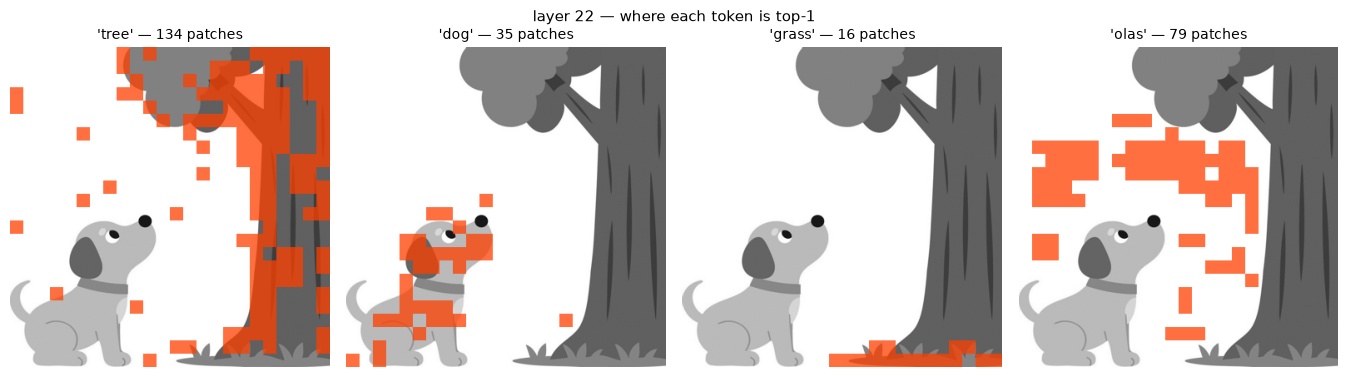

In [11]:
def patch_mask(layer, token):
    """Boolean 24 x 24 mask of patches whose top-1 token is `token`."""
    mask = np.zeros((GRID, GRID), dtype=bool)
    for index, position in enumerate(image_positions):
        if top1_at(layer, position) == token:
            mask[divmod(index, GRID)] = True
    return mask

def show_masks(layer, tokens, title):
    backdrop = np.asarray(image.convert("L").resize((GRID * 16, GRID * 16))) / 255
    fig, axes = plt.subplots(1, len(tokens), figsize=(3.4 * len(tokens), 3.8))
    for ax, token in zip(np.atleast_1d(axes), tokens):
        mask = patch_mask(layer, token)
        ax.imshow(backdrop, cmap="gray", vmin=0, vmax=1)
        overlay = np.zeros((GRID, GRID, 4))
        overlay[mask] = [1.0, 0.25, 0.0, 0.75]
        ax.imshow(np.kron(overlay, np.ones((16, 16, 1))))
        ax.set_title(f"{token!r} — {int(mask.sum())} patches", fontsize=10)
        ax.axis("off")
    fig.suptitle(title, fontsize=11)
    plt.tight_layout()
    plt.show()

show_masks(22, ["tree", "dog", "grass", "olas"], "layer 22 — where each token is top-1")

`'tree'` lands on the trunk and the branch, and almost nowhere else. `'grass'` picks out the
strip at the base. `'dog'` is sparser than the others but sits on the animal rather than
scattered across the frame — which is the claim being tested: the readout is not just producing
plausible words for the picture as a whole, it is producing them *at the right patches*.

`'olas'` is the control, and an honest one. It is not a word — it is a junk token the readout
falls back on, and it covers most of the blank background. A large fraction of the grid is
saying nothing, and any description of this as "segmentation" has to account for that.

### Across depth

The same mask for one token, at four depths — the emergence and collapse from the table above,
made spatial.

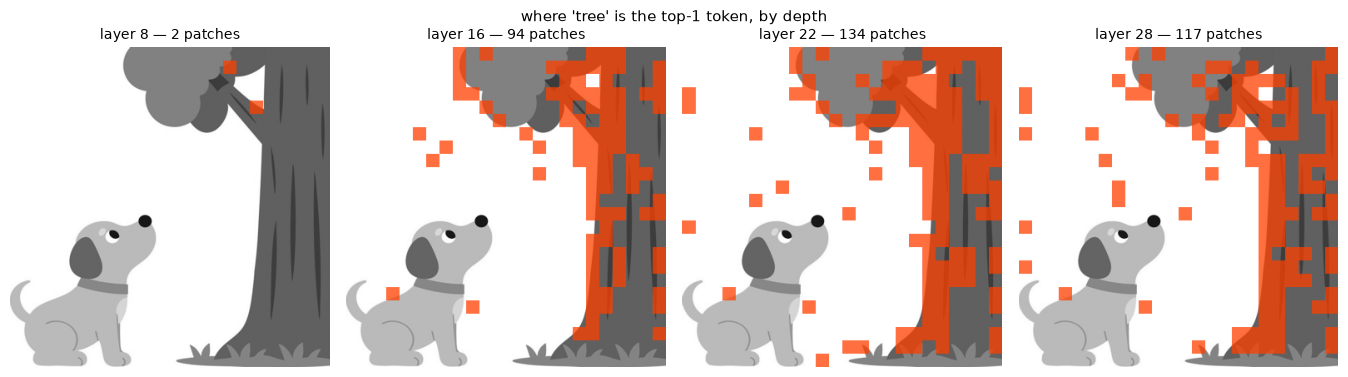

In [12]:
backdrop = np.asarray(image.convert("L").resize((GRID * 16, GRID * 16))) / 255
fig, axes = plt.subplots(1, 4, figsize=(13.6, 3.8))
for ax, layer in zip(axes, [8, 16, 22, 28]):
    mask = patch_mask(layer, "tree")
    ax.imshow(backdrop, cmap="gray", vmin=0, vmax=1)
    overlay = np.zeros((GRID, GRID, 4))
    overlay[mask] = [1.0, 0.25, 0.0, 0.75]
    ax.imshow(np.kron(overlay, np.ones((16, 16, 1))))
    ax.set_title(f"layer {layer} — {int(mask.sum())} patches", fontsize=10)
    ax.axis("off")
fig.suptitle("where 'tree' is the top-1 token, by depth", fontsize=11)
plt.tight_layout()
plt.show()

At layer 8 the token barely appears. By 16 it has found the trunk. At 22 it covers the tree
properly. At 28 it is still there but eroding, as those positions get taken over by the
next-token machinery.

Worth being precise about what this is and is not. It is not a segmentation model: the
boundaries are patch-quantised, `'dog'` only claims a third of the animal, and most of the
background is junk. What it *is* is evidence that by the middle of the decoder an image patch's
residual stream has moved close enough to a word embedding that the model's own unembedding
lands on the right word — with no probe, no training, and no supervision.

## Conclusion

🎉 A vision model's patches turn out to be readable with a text model's unembedding, in the
middle of the network, with no probe and no training — one forward pass and the model's own
final norm applied 32 times.

The `nnsight` shape of it is worth noting for how little there is: the only thing that makes
this a *vision* experiment rather than a text one is the processor call. After that,
`layer.output` is `layer.output`, and reading 576 image positions is the same operation as
reading 17 text ones.

Related: [Logit Lens](../tutorials/probing/logit_lens.ipynb) for the text-only version,
[Cross-Attention Ablation](../tutorials/vision/cross-attention-ablation.ipynb) for intervening on a
vision model instead of reading it, and
[Module Access](../../features/6_modules.ipynb) for calling modules ad hoc inside a trace.

## References

- Neo, Ong, Torr, Geva, Krueger, Barez, [*Towards Interpreting Visual Information Processing in Vision-Language Models*](https://arxiv.org/abs/2410.07149), 2024
- Liu, Li, Wu, Lee, [*Visual Instruction Tuning*](https://arxiv.org/abs/2304.08485) (LLaVA), NeurIPS 2023
- nostalgebraist, [*Interpreting GPT: the Logit Lens*](https://www.lesswrong.com/posts/AcKRB8wDpdaN6v6ru/interpreting-gpt-the-logit-lens), 2020
- CVPR 2026 HOW workshop companion code — [github.com/JadenFiotto-Kaufman/CVPR2026-HOW](https://github.com/JadenFiotto-Kaufman/CVPR2026-HOW)